# 04 — Metaheurística: Búsqueda Tabú HDM

Análisis de la **metaheurística de búsqueda tabú** para el modelo HDM, resuelta por el
motor **C++** (`src/metaheuristica`) y volcada a JSON con el mismo esquema que exacto y
lagrangiana (`z`/`x`/`w`/`y_assign`): `analisis` la consume **sin distinguir método**.

Se comparan los **dos modos** del solver:
- **entero** — activación por punto `open[j]` (un punto abierto ofrece todos los tipos).
- **per-tipo** — activación por punto y tipo `active[j][k]` (se decide tipo a tipo).

Narrativa + llamadas a `analisis`, sin lógica inline. Tamaños resueltos: **500, 1000,
1500 m** (ambos modos). El exacto entra solo como **referencia** de calidad; la
comparación en profundidad de los tres métodos es el cuaderno 05. El tabú **no reporta
gap** (no tiene cota dual) y, a diferencia de exacto/lagrangiana, **puede entregar
soluciones infactibles** — ambas cosas se hacen visibles abajo.

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, "../src/python")   # mínimo para importar 'analisis' (patrón 01/02/03)

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown

from instancia import load_instance
from analisis import carga, estilo, rutas, metricas, comparativas
# 'mapas' (osmnx/geopandas) se importa en §5, NO aquí (mantiene geo-free el resto).

RAIZ = rutas.raiz_repo()
TAMS = [500, 1000, 1500]                       # tamaños con solución tabú (los dos modos)
MODOS = {"per-tipo": "pertipo", "entero": "entero"}   # etiqueta -> infijo del fichero C++

INST = {t: load_instance(str(rutas.ruta_instancia(t))) for t in TAMS}

def _ruta_tabu(infijo, tam):   # esquema nuevo del C++: output/metaheuristica/...
    return RAIZ / "output" / "metaheuristica" / f"solucion_tabu_{infijo}_{tam}m.json"

def _ruta_exacta(tam):         # layout viejo (D6), como referencia
    return RAIZ / "output" / f"exacto_{tam}m" / "solucion_exacta.json"

# Diccionario (etiqueta_metodo, tam) -> Solucion, para acceso directo.
SOLS = {}
for etiqueta, infijo in MODOS.items():
    for t in TAMS:
        datos = carga.cargar_solucion(str(_ruta_tabu(infijo, t)))
        SOLS[(f"tabú ({etiqueta})", t)] = comparativas.Solucion(f"tabú ({etiqueta})", t, datos, INST[t])
for t in TAMS:
    SOLS[("exacto", t)] = comparativas.Solucion("exacto", t, carga.cargar_solucion(str(_ruta_exacta(t))), INST[t])

TABU_PT = [SOLS[("tabú (per-tipo)", t)] for t in TAMS]
TABU_EN = [SOLS[("tabú (entero)", t)]   for t in TAMS]
EXACTO  = [SOLS[("exacto", t)]          for t in TAMS]
TODOS   = EXACTO + TABU_EN + TABU_PT

for et in ("tabú (per-tipo)", "tabú (entero)"):
    linea = "  ".join(
        f"{t}m={metricas.coste(SOLS[(et,t)].datos):,.0f}€(modo={SOLS[(et,t)].datos.get('modo')})"
        for t in TAMS)
    print(f"{et:16}: {linea}")

tabú (per-tipo) : 500m=347,840€(modo=per-tipo)  1000m=1,046,170€(modo=per-tipo)  1500m=2,253,920€(modo=per-tipo)
tabú (entero)   : 500m=369,660€(modo=entero)  1000m=1,081,520€(modo=entero)  1500m=2,619,030€(modo=entero)


## 2. Resultados comparativos

Tabla agnóstica (`comparativas.tabla_resumen`) de los dos modos del tabú frente al exacto,
y **distancia al óptimo** (`comparar_metodos`, referencia = exacto). El tabú **no reporta
gap** → esa columna queda vacía; su calidad se mide por la distancia al exacto. Debajo, la
**factibilidad** (violaciones de capacidad, `metricas`): a diferencia del exacto y la
lagrangiana, el tabú puede entregar soluciones que exceden el límite físico de bins.

,metodo,tam,coste,n_puntos,n_bins,gap,tiempo
0,exacto,500,343070.0,64,208,0.000087,705.619657
1,exacto,1000,1007010.0,182,646,0.005968,14400.167372
2,exacto,1500,2265500.0,403,1461,0.053269,8178.187288
3,tabú (entero),500,369660.0,65,265,NaN,12.240791
4,tabú (entero),1000,1081520.0,185,801,NaN,35.380147
5,tabú (entero),1500,2619030.0,407,1799,NaN,61.744616
6,tabú (per-tipo),500,347840.0,65,211,NaN,19.126232
7,tabú (per-tipo),1000,1046170.0,189,669,NaN,56.007441
8,tabú (per-tipo),1500,2253920.0,397,1482,NaN,102.231675


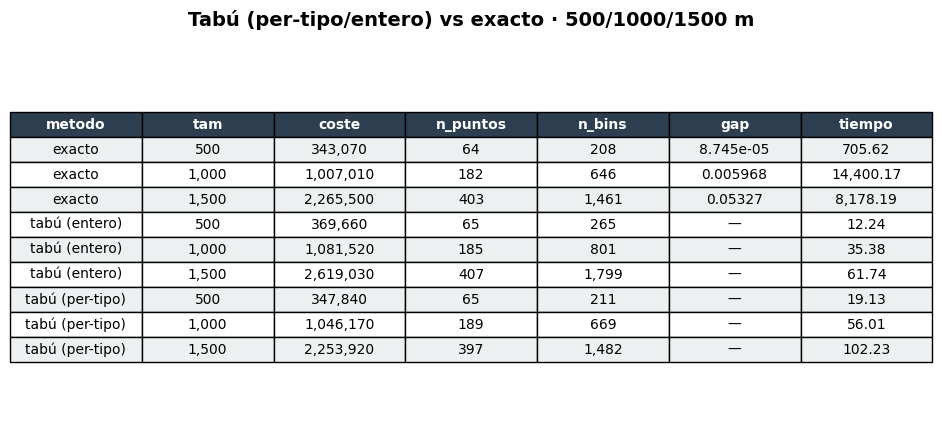

In [ ]:
df = comparativas.tabla_resumen(TODOS)
display(df)

ax = comparativas.tabla_matplotlib(df, titulo="Tabú (per-tipo/entero) vs exacto · 500/1000/1500 m")
ruta = rutas.ruta_figura("04_tabla_resumen")
ruta.parent.mkdir(parents=True, exist_ok=True)
ax.figure.savefig(ruta, dpi=120, bbox_inches="tight")
plt.show()

In [ ]:
# Distancia al óptimo (gap_vs_ref = (coste_tabú − óptimo) / óptimo).
comp = comparativas.comparar_metodos(
    {"exacto": EXACTO, "tabú (per-tipo)": TABU_PT, "tabú (entero)": TABU_EN},
    referencia="exacto")
display(comp)

,tam,metodo,coste,coste_ref,referencia,gap_vs_ref
0,500,tabú (entero),369660.0,343070.0,exacto,0.077506
1,1000,tabú (entero),1081520.0,1007010.0,exacto,0.073991
2,1500,tabú (entero),2619030.0,2265500.0,exacto,0.156049
3,500,tabú (per-tipo),347840.0,343070.0,exacto,0.013904
4,1000,tabú (per-tipo),1046170.0,1007010.0,exacto,0.038887
5,1500,tabú (per-tipo),2253920.0,2265500.0,exacto,-0.005111


In [ ]:
# Factibilidad (glue de presentación): violaciones de capacidad por modo/tamaño.
filas = []
for et in ("tabú (per-tipo)", "tabú (entero)"):
    for t in TAMS:
        r = metricas.resumen(SOLS[(et, t)].datos, INST[t])
        filas.append({
            "modo": et, "tam": t,
            "coste": metricas.coste(SOLS[(et, t)].datos),
            "puntos": r["n_puntos_abiertos"], "bins": r["total_bins"],
            "viol_capacidad": r["n_violaciones_capacidad"],
            "factible": r["n_violaciones_capacidad"] == 0,
        })
display(pd.DataFrame(filas))

,modo,tam,coste,puntos,bins,viol_capacidad,factible
0,tabú (per-tipo),500,347840.0,65,211,0,True
1,tabú (per-tipo),1000,1046170.0,189,669,0,True
2,tabú (per-tipo),1500,2253920.0,397,1482,0,True
3,tabú (entero),500,369660.0,65,265,0,True
4,tabú (entero),1000,1081520.0,185,801,0,True
5,tabú (entero),1500,2619030.0,407,1799,2,False


## 3. Per-tipo vs entero

El salto de modelo **`open[j]` → `active[j][k]`** (entero → per-tipo) es la aportación
central. Al decidir la activación **tipo a tipo**, el per-tipo evita instalar contenedores
de tipos innecesarios en un punto: menos bins, menor coste y mejor factibilidad. Los
números —leídos de las soluciones, no fijados— cuantifican la mejora.

In [ ]:
def _coste(et, t):
    return metricas.coste(SOLS[(et, t)].datos)

partes = ["**Per-tipo vs entero.** "]
for t in TAMS:
    c_ex = _coste("exacto", t)
    c_pt = _coste("tabú (per-tipo)", t)
    c_en = _coste("tabú (entero)", t)
    mejora = (c_en - c_pt) / c_en
    partes.append(
        f"A **{t} m**: per-tipo **{c_pt:,.0f} €** vs entero **{c_en:,.0f} €** "
        f"({mejora:+.1%}); distancia al óptimo {(c_pt - c_ex) / c_ex:+.2%} (per-tipo) "
        f"vs {(c_en - c_ex) / c_ex:+.2%} (entero). ")

# Factibilidad del entero.
infact = [(t, metricas.resumen(SOLS[("tabú (entero)", t)].datos, INST[t])["n_violaciones_capacidad"])
          for t in TAMS]
infact = [(t, v) for t, v in infact if v > 0]
if infact:
    detalle = ", ".join(f"{t} m ({v} violaciones)" for t, v in infact)
    partes.append(f"El modo **entero** entrega soluciones **infactibles** en {detalle}; "
                  f"el per-tipo es factible en todos los tamaños. ")

# Instancia mayor vs exacto (dato volátil: se lee el estado del exacto dinámicamente).
tmax = max(TAMS)
est_ex = estilo.estado_gurobi(SOLS[("exacto", tmax)].datos["status"])
dist_max = (_coste("tabú (per-tipo)", tmax) - _coste("exacto", tmax)) / _coste("exacto", tmax)
partes.append(
    f"En la instancia mayor (**{tmax} m**) el exacto está en estado **{est_ex}** "
    f"({'óptimo demostrado' if est_ex == 'óptimo' else 'sin óptimo demostrado'}): la tabú "
    f"per-tipo queda a **{dist_max:+.2%}** de él" + (" —lo mejora—." if dist_max < 0 else "."))

display(Markdown("".join(partes)))

**Per-tipo vs entero.** A **500 m**: per-tipo **347,840 €** vs entero **369,660 €** (+5.9%); distancia al óptimo +1.39% (per-tipo) vs +7.75% (entero). A **1000 m**: per-tipo **1,046,170 €** vs entero **1,081,520 €** (+3.3%); distancia al óptimo +3.89% (per-tipo) vs +7.40% (entero). A **1500 m**: per-tipo **2,253,920 €** vs entero **2,619,030 €** (+13.9%); distancia al óptimo -0.51% (per-tipo) vs +15.60% (entero). El modo **entero** entrega soluciones **infactibles** en 1500 m (2 violaciones); el per-tipo es factible en todos los tamaños. En la instancia mayor (**1500 m**) el exacto está en estado **interrumpido** (sin óptimo demostrado): la tabú per-tipo queda a **-0.51%** de él —lo mejora—.

## 4. Escalabilidad

Coste, tiempo de resolución y nº de puntos abiertos frente al tamaño, para los dos modos
del tabú y el exacto de referencia (`comparativas.grafico_escalabilidad`, 3 tamaños). El
panel de **tiempo** (eje log) muestra la ventaja de la metaheurística: **segundos** frente
a los minutos/horas del exacto.

Figura guardada: output/figuras/04_escalabilidad.png


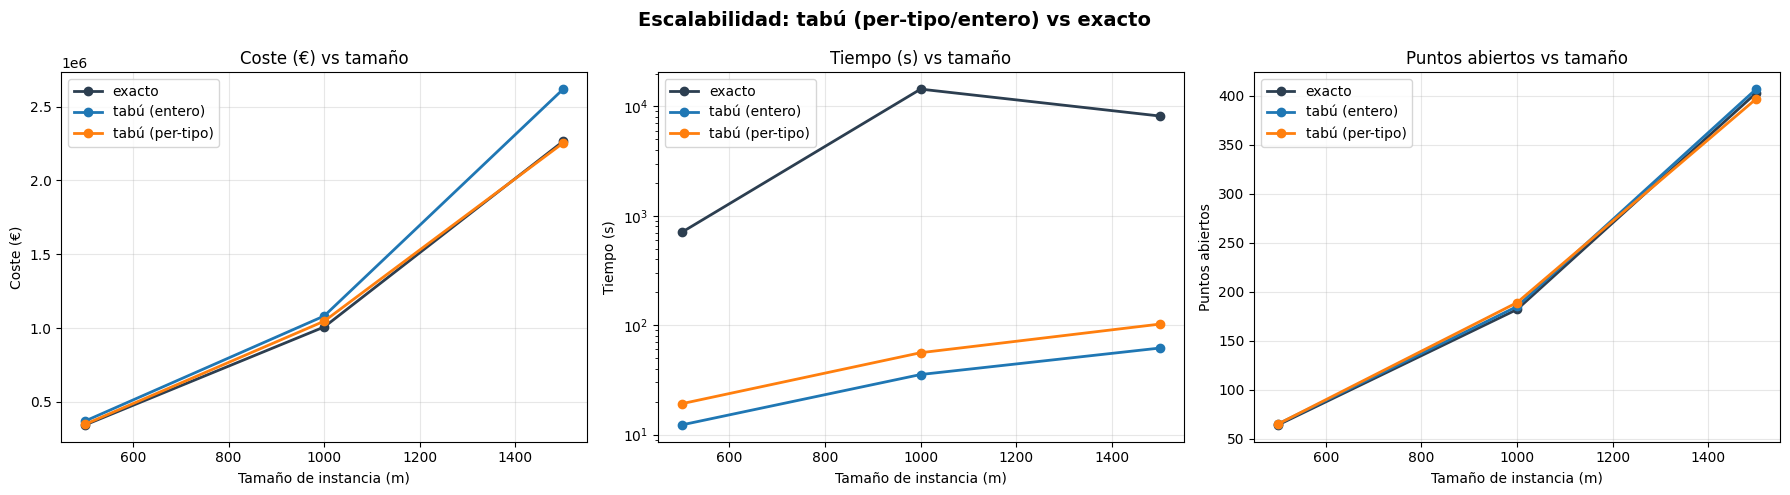

In [ ]:
ejes = comparativas.grafico_escalabilidad(TODOS, columnas=("coste", "tiempo", "n_puntos"))
plt.suptitle("Escalabilidad: tabú (per-tipo/entero) vs exacto", fontsize=14, fontweight="bold")
plt.tight_layout()
ruta = rutas.ruta_figura("04_escalabilidad")
ruta.parent.mkdir(parents=True, exist_ok=True)
ejes[0].figure.savefig(ruta, dpi=120, bbox_inches="tight")
print(f"Figura guardada: {ruta.relative_to(RAIZ)}")
plt.show()

## 5. Mapas de solución (per-tipo)

Solución del modo **per-tipo** (el mejor) sobre el callejero, con `mapas.mapa_solucion` (la
misma función única de 02/03; la solución llega ya normalizada por `cargar_solucion`, sin
nada específico de método). Muestra `RADIOS_MUESTRA ∩ resueltos`. Puntos abiertos con
tamaño ∝ nº de contenedores y color ∝ demanda asignada.

Figura guardada: output/figuras/04_solucion_pertipo_500m.png


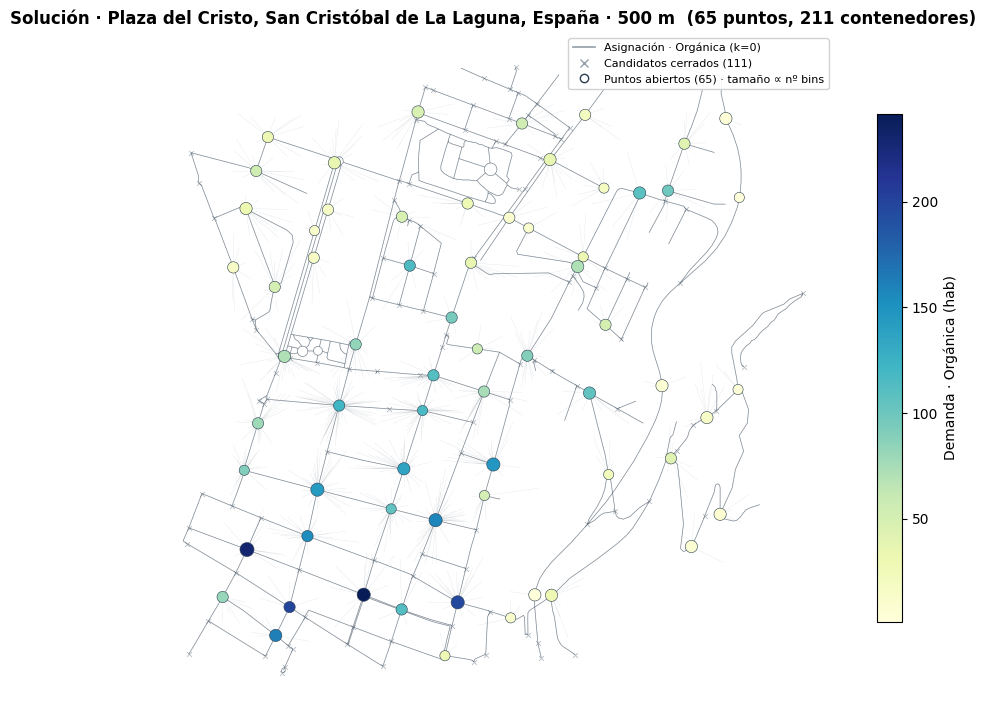

Figura guardada: output/figuras/04_solucion_pertipo_1000m.png


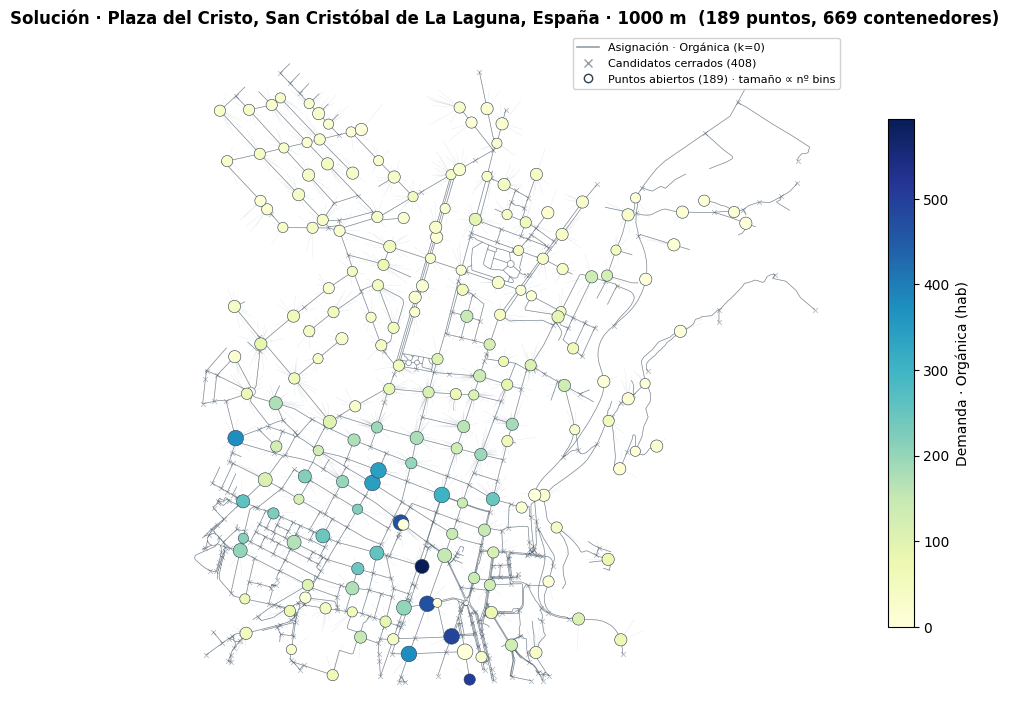

Figura guardada: output/figuras/04_solucion_pertipo_1500m.png


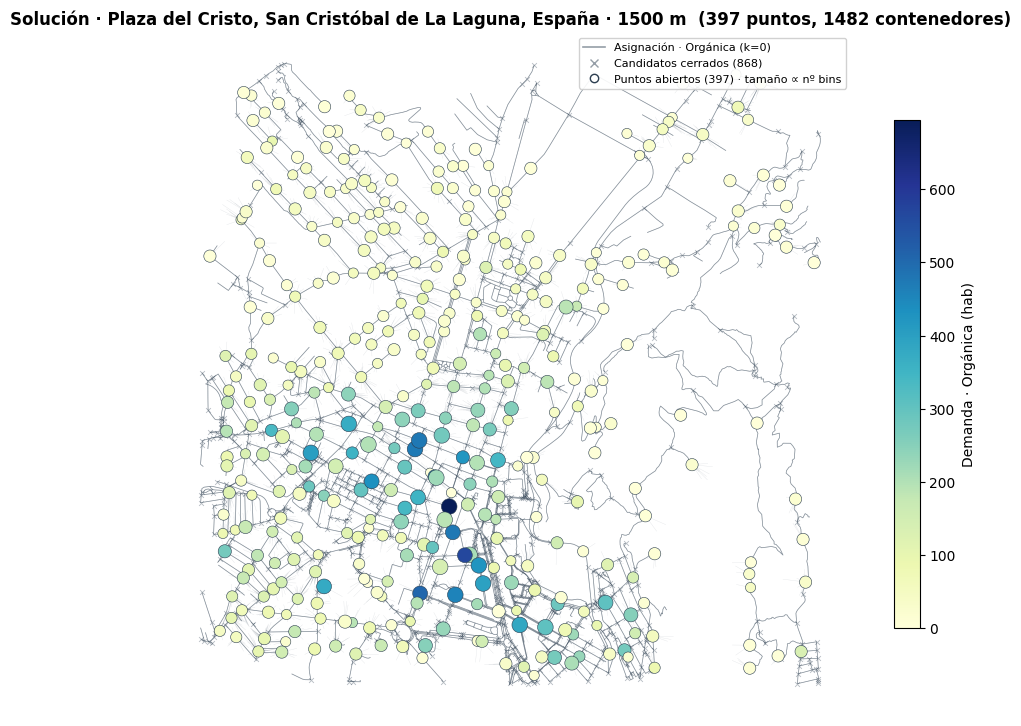

In [ ]:
from analisis import mapas   # osmnx/geopandas: se importan AQUÍ, no al top (geo-free arriba)

MUESTRA = [t for t in estilo.RADIOS_MUESTRA if t in TAMS]   # [500, 1000, 1500]
for t in MUESTRA:
    s = SOLS[("tabú (per-tipo)", t)]
    ax = mapas.mapa_solucion(s.datos, s.inst, rich=True)
    ruta = rutas.ruta_figura(f"04_solucion_pertipo_{t}m")
    ruta.parent.mkdir(parents=True, exist_ok=True)
    ax.figure.savefig(ruta, dpi=120, bbox_inches="tight")
    print(f"Figura guardada: {ruta.relative_to(RAIZ)}")
    plt.show()

## 6. Conclusiones

El modo **per-tipo domina al entero** en los tres tamaños —menos contenedores y menor
coste—, y sin violaciones de capacidad, mientras el entero llega a entregar soluciones
**infactibles**. Es la evidencia a favor del salto de modelo `open[j] → active[j][k]`.
Frente al exacto, el tabú per-tipo se queda a pocos puntos porcentuales del óptimo en una
**fracción del tiempo** (segundos vs minutos/horas) y, en la instancia mayor —donde hoy
Gurobi no cierra el gap—, alcanza una solución **competitiva o mejor** (§3). La
metaheurística es, por tanto, la vía práctica para los tamaños donde el exacto deja de ser
viable. La comparación conjunta de los tres métodos se cierra en el cuaderno 05.